# CNN-LSTM Benchmark (Google Colab)

Deep learning benchmark to test whether tabular transaction data has
spatial/sequential structure that Conv1D and LSTM layers can exploit.
Each transaction is treated as an independent feature vector rather than
a true per-user sequence -- average UID history is only 2.2 transactions
(Notebook 03), too short for genuine sequence modelling.

Run with GPU runtime enabled. Upload `train_engineered.parquet` before running.

In [ ]:
# Colab Setup

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install tensorflow -q
    DATA_PATH = 'train_engineered.parquet'
else:
    DATA_PATH = '../data/train_engineered.parquet'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
import joblib

warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

train = pd.read_parquet(DATA_PATH)
print(f'Shape: {train.shape}')
print(f'Fraud rate: {train["isFraud"].mean():.2%}')

TensorFlow version: 2.20.0
GPU available: True
Shape: (590540, 455)
Fraud rate: 3.50%


In [ ]:
# Train/Test Split (same as Notebook 04)

train = train.sort_values('TransactionDT').reset_index(drop=True)

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in train.columns]
FEATURES   = [c for c in train.columns if c not in DROP_COLS]

X = train[FEATURES].fillna(0).values
y = train[TARGET].values

split_idx  = int(len(train) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scale features (neural networks require normalized input)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Reshape for CNN-LSTM: (samples, timesteps, features)
# We treat each feature as a "timestep" for the LSTM
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'X_train shape: {X_train_3d.shape}')
print(f'X_test shape:  {X_test_3d.shape}')

# Class weights for imbalanced data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weight for fraud: {class_weight[1]:.1f}')

X_train shape: (472432, 421, 1)
X_test shape:  (118108, 421, 1)
Class weight for fraud: 27.5


In [6]:
# ── CNN-LSTM Architecture ─────────────────────────────────────────────────────
#
# Architecture design:
# - Conv1D: extract local feature interactions (spatial patterns)
# - LSTM:   capture sequential dependencies (temporal patterns)
# - Dense:  final classification
#
# Reference: "Hybrid CNN-LSTM with Attention for Credit Card Fraud" (IEEE Access, 2025)

def build_cnn_lstm(input_shape, dropout_rate=0.3):
    inputs = keras.Input(shape=input_shape)

    # CNN block: spatial feature extraction
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # LSTM block: temporal sequence modelling
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Classification head
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_cnn_lstm(input_shape=(X_train_3d.shape[1], 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 421, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 421, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 421, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 421, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 210, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 210, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 210, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,025 (175.88 KB)

 Trainable params: 44,897 (175.38 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Training

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(curve='PR', name='auc_pr')]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=3, mode='max'
    )
]

print('Training CNN-LSTM...')
history = model.fit(
    X_train_3d, y_train,
    validation_data=(X_test_3d, y_test),
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Training CNN-LSTM...
Epoch 1/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 62s 191ms/step - auc: 0.7652 - auc_pr: 0.1261 - loss: 1.1163 - val_auc: 0.7805 - val_auc_pr: 0.1401 - val_loss: 0.4556 - learning_rate: 0.0010
Epoch 2/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 43s 186ms/step - auc: 0.8097 - auc_pr: 0.2532 - loss: 1.0182 - val_auc: 0.8109 - val_auc_pr: 0.2775 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 3/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 191ms/step - auc: 0.8187 - auc_pr: 0.2914 - loss: 0.9953 - val_auc: 0.8304 - val_auc_pr: 0.3281 - val_loss: 0.4816 - learning_rate: 0.0010
Epoch 4/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 82s 193ms/step - auc: 0.8253 - auc_pr: 0.3001 - loss: 0.9807 - val_auc: 0.8297 - val_auc_pr: 0.3348 - val_loss: 0.4626 - learning_rate: 0.0010
Epoch 5/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 191ms/step - auc: 0.8326 - auc_pr: 0.3292 - loss: 0.9604 - val_auc: 0.8335 - val_auc_pr: 0.3304 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 6/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 191ms/step - auc: 0.

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step

=== CNN-LSTM RESULTS ===
AUC-ROC:   0.8635
AUC-PR:    0.3918
F1:        0.2094

-> Copy these numbers into Notebook 04 results table


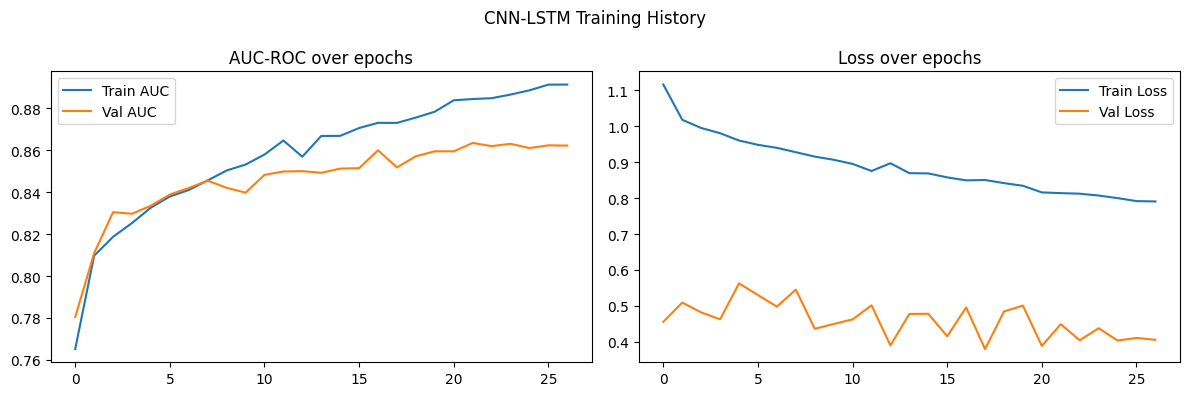

Saved: cnn_lstm_training.png
Download this file and add to reports/ folder in your repository


In [ ]:
# Evaluation

cnn_proba = model.predict(X_test_3d, batch_size=2048).flatten()
cnn_pred  = (cnn_proba >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test, cnn_proba)
auc_pr  = average_precision_score(y_test, cnn_proba)
f1      = f1_score(y_test, cnn_pred)

print('\n=== CNN-LSTM RESULTS ===')
print(f'AUC-ROC:   {auc_roc:.4f}')
print(f'AUC-PR:    {auc_pr:.4f}')
print(f'F1:        {f1:.4f}')
print('\n-> Copy these numbers into Notebook 04 results table')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['auc'], label='Train AUC')
axes[0].plot(history.history['val_auc'], label='Val AUC')
axes[0].set_title('AUC-ROC over epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over epochs')
axes[1].legend()

plt.suptitle('CNN-LSTM Training History')
plt.tight_layout()
plt.savefig('cnn_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_lstm_training.png')
print('Download this file and add to reports/ folder in your repository')

In [ ]:
# Inference time benchmark

# Single transaction inference on CPU
single_input = X_test_3d[:1]

times = []
for _ in range(100):
    start = time.time()
    _ = model.predict(single_input, verbose=0)
    times.append((time.time() - start) * 1000)

avg_ms = np.mean(times)
print(f'Average inference time (single transaction): {avg_ms:.1f}ms')
print(f'Meets <300ms requirement: {"YES" if avg_ms < 300 else "NO"}')
print('\nNote: This is measured on Colab GPU/CPU. Real deployment on CPU will be slower.')

Average inference time (single transaction): 76.5ms
Meets <300ms requirement: YES

Note: This is measured on Colab GPU/CPU. Real deployment on CPU will be slower.


## Cost-Sensitive Threshold Optimization

Same protocol as Notebook 04, applied to CNN-LSTM's predictions.


In [ ]:
COST_FP = 10     # False Positive: customer friction ($)
COST_FN_amounts = None  # placeholder, filled below

test_amounts = train['TransactionAmt'].iloc[split_idx:].values

thresholds  = np.arange(0.05, 0.95, 0.01)
total_costs = []
f1_scores_sweep = []

for thresh in thresholds:
    preds = (cnn_proba >= thresh).astype(int)

    # False Negatives: fraud we missed -> cost = actual transaction amount
    fn_mask = (preds == 0) & (y_test == 1)
    fn_cost = test_amounts[fn_mask].sum()

    # False Positives: legit we blocked -> cost = flat $10
    fp_mask = (preds == 1) & (y_test == 0)
    fp_cost = fp_mask.sum() * COST_FP

    total_costs.append(fn_cost + fp_cost)
    f1_scores_sweep.append(f1_score(y_test, preds))

total_costs = np.array(total_costs)
optimal_idx    = np.argmin(total_costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost   = total_costs[optimal_idx]

# No-model baseline cost (catch nothing)
no_model_cost = test_amounts[y_test == 1].sum()
savings     = no_model_cost - optimal_cost
savings_pct = savings / no_model_cost * 100

print('=== CNN-LSTM Cost-Sensitive Threshold Optimization ===')
print(f'Optimal threshold:     {optimal_thresh:.2f}')
print(f'Total cost at optimal: ${optimal_cost:,.0f}')
print(f'No-model cost:         ${no_model_cost:,.0f}')
print(f'Savings:               ${savings:,.0f} ({savings_pct:.1f}%)')
print(f'\n-> Compare this savings % against Notebook 04 (LightGBM/XGBoost) and 04b (Stacking)')

=== CNN-LSTM Cost-Sensitive Threshold Optimization ===
Optimal threshold:     0.69
Total cost at optimal: $338,813
No-model cost:         $609,934
Savings:               $271,121 (44.5%)

-> Compare this savings % against Notebook 04 (LightGBM/XGBoost) and 04b (Stacking)


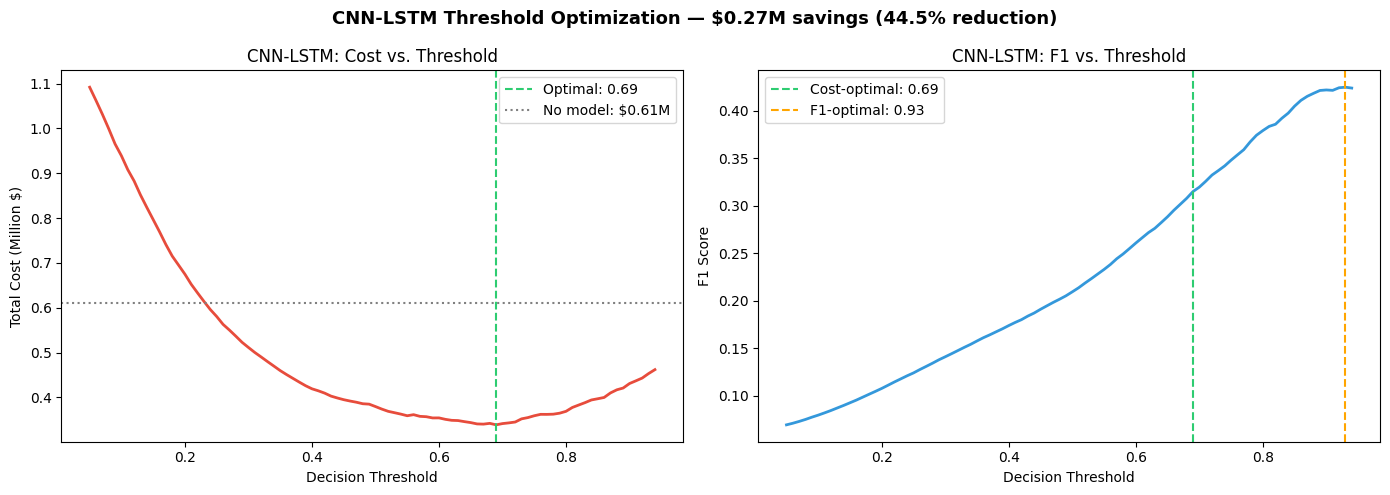

Saved: cnn_lstm_threshold_optimization.png
Download this file and add it to reports/ in your repository


In [ ]:
# Plot: Cost vs Threshold (CNN-LSTM)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, total_costs / 1e6, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Optimal: {optimal_thresh:.2f}')
axes[0].axhline(no_model_cost / 1e6, color='gray', linestyle=':',
                label=f'No model: ${no_model_cost/1e6:.2f}M')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (Million $)')
axes[0].set_title('CNN-LSTM: Cost vs. Threshold')
axes[0].legend()

axes[1].plot(thresholds, f1_scores_sweep, color='#3498db', linewidth=2)
axes[1].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Cost-optimal: {optimal_thresh:.2f}')
f1_optimal_idx = np.argmax(f1_scores_sweep)
axes[1].axvline(thresholds[f1_optimal_idx], color='orange', linestyle='--',
                label=f'F1-optimal: {thresholds[f1_optimal_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('CNN-LSTM: F1 vs. Threshold')
axes[1].legend()

plt.suptitle(f'CNN-LSTM Threshold Optimization — ${savings/1e6:.2f}M savings ({savings_pct:.1f}% reduction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_lstm_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_lstm_threshold_optimization.png')
print('Download this file and add it to reports/ in your repository')

In [ ]:
# Save predictions so we don't lose them if the Colab runtime disconnects

joblib.dump(cnn_proba, 'cnn_proba.pkl')
joblib.dump(y_test, 'y_test_cnn.pkl')
joblib.dump(test_amounts, 'test_amounts_cnn.pkl')
joblib.dump({
    'optimal_threshold': optimal_thresh,
    'optimal_cost': optimal_cost,
    'no_model_cost': no_model_cost,
    'savings': savings,
    'savings_pct': savings_pct
}, 'cnn_lstm_cost_results.pkl')

print('Saved: cnn_proba.pkl, y_test_cnn.pkl, test_amounts_cnn.pkl, cnn_lstm_cost_results.pkl')
print('Download these now via the Colab file browser (left sidebar) before the session ends.')

Saved: cnn_proba.pkl, y_test_cnn.pkl, test_amounts_cnn.pkl, cnn_lstm_cost_results.pkl
Download these now via the Colab file browser (left sidebar) before the session ends.


In [ ]:
# Save the actual Keras model for local inference benchmarking

model.save('cnn_lstm_model.keras')
print('Saved: cnn_lstm_model.keras')
print('Download this file now via the Colab file browser (left sidebar) before the session ends.')

Saved: cnn_lstm_model.keras
Download this file now via the Colab file browser (left sidebar) before the session ends.
